In [5]:
!pip install geopandas folium plotly seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Data Processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Geospatial Visualization
import geopandas as gpd
import folium

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [7]:
file_path = r"C:\Users\Admin\Downloads\database.csv.zip"

df = pd.read_csv(file_path, compression='zip')

# check first rows
df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [8]:
df.isnull().sum()

Declaration Number                      0
Declaration Type                        0
Declaration Date                        0
State                                   0
County                                197
Disaster Type                           0
Disaster Title                          0
Start Date                              0
End Date                              342
Close Date                          10975
Individual Assistance Program           0
Individuals & Households Program        0
Public Assistance Program               0
Hazard Mitigation Program               0
dtype: int64

In [14]:
df = df.dropna(subset=['State'])

df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [15]:
state_disasters = df.groupby('State').size().reset_index(name='Disaster_Count')

state_disasters = state_disasters.sort_values(
    by='Disaster_Count',
    ascending=False
)

state_disasters.head(10)

,State,Disaster_Count
50,TX,3842
28,MO,2263
20,KY,2026
52,VA,1982
41,OK,1882
10,FL,1512
15,IA,1471
12,GA,1406
21,LA,1393
32,NC,1312


In [16]:
state_disaster_type = df.groupby(['State','Disaster Type']).size().reset_index(name='Count')

state_disaster_type.head()

,State,Disaster Type,Count
0,AK,Earthquake,7
1,AK,Fire,16
2,AK,Flood,46
3,AK,Other,4
4,AK,Snow,4


In [17]:
top_states = state_disasters.head(10)

top_states

,State,Disaster_Count
50,TX,3842
28,MO,2263
20,KY,2026
52,VA,1982
41,OK,1882
10,FL,1512
15,IA,1471
12,GA,1406
21,LA,1393
32,NC,1312


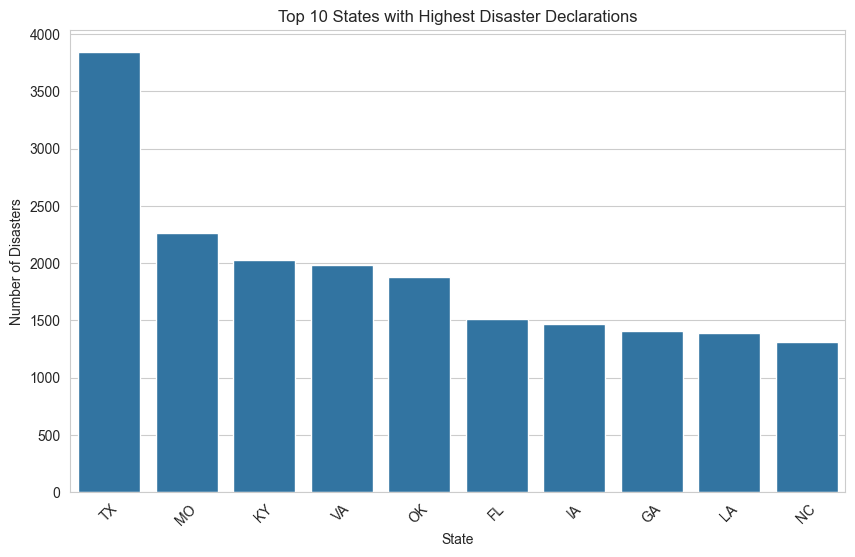

In [18]:
plt.figure()

sns.barplot(
    data=top_states,
    x='State',
    y='Disaster_Count'
)

plt.title("Top 10 States with Highest Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.xticks(rotation=45)

plt.show()

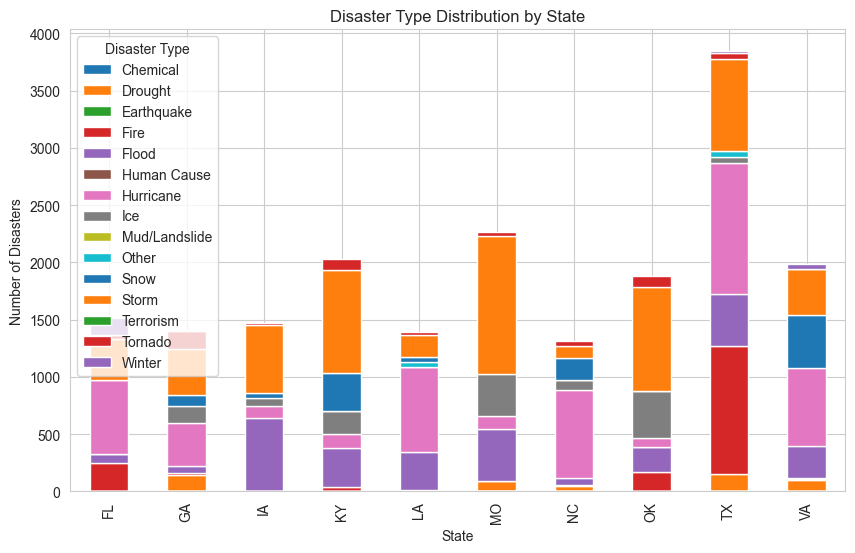

In [19]:
top_state_list = top_states['State'].tolist()

filtered = state_disaster_type[
    state_disaster_type['State'].isin(top_state_list)
]

pivot_table = filtered.pivot(
    index='State',
    columns='Disaster Type',
    values='Count'
).fillna(0)

pivot_table.plot(
    kind='bar',
    stacked=True
)

plt.title("Disaster Type Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.legend(title="Disaster Type")

plt.show()

In [23]:
state_codes = {
'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA',
'Kansas':'KS','Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH',
'New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC',
'North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA',
'Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD','Tennessee':'TN',
'Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}

df['State_Code'] = df['State'].map(state_codes)

df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program,State_Code
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes,NaN
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes,NaN
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes,NaN
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes,NaN
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes,NaN


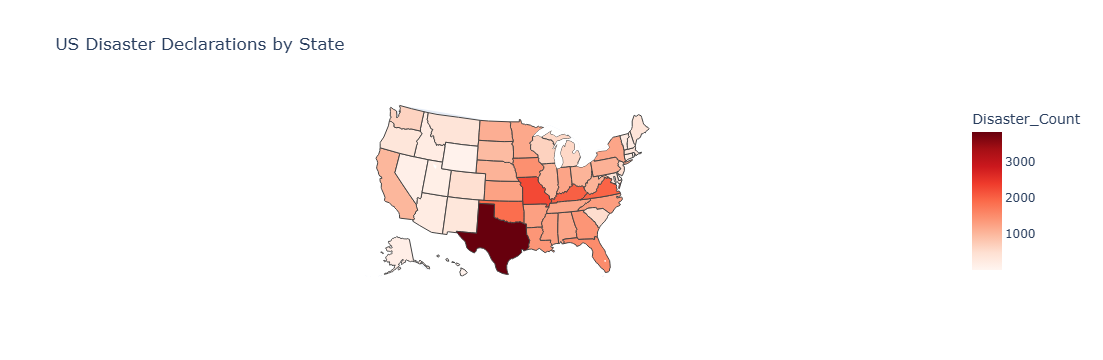

In [26]:
state_disasters = df.groupby('State').size().reset_index(name='Disaster_Count')

fig = px.choropleth(
    state_disasters,
    locations='State',
    locationmode="USA-states",
    color='Disaster_Count',
    scope="usa",
    color_continuous_scale="Reds",
    title="US Disaster Declarations by State"
)

fig.show()

In [33]:
df['Declaration Date'] = pd.to_datetime(df['Declaration Date'])

df['Year'] = df['Declaration Date'].dt.year

In [34]:
state_year_disasters = df.groupby(['Year','State']).size().reset_index(name='Disaster_Count')

state_year_disasters.head()

,Year,State,Disaster_Count
0,1953,AK,1
1,1953,FL,1
2,1953,GA,1
3,1953,IA,1
4,1953,LA,1


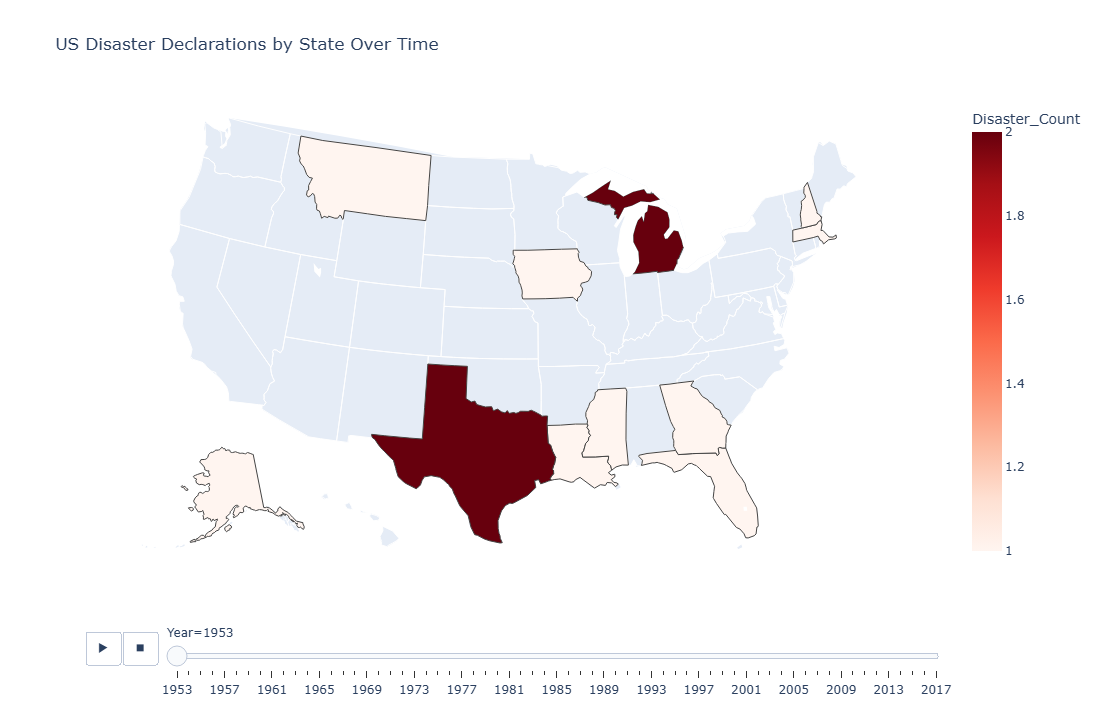

In [36]:
import plotly.express as px

fig = px.choropleth(
    state_year_disasters,
    locations='State',
    locationmode="USA-states",
    color='Disaster_Count',
    scope="usa",
    animation_frame='Year',
    color_continuous_scale="Reds",
    title="US Disaster Declarations by State Over Time"
)

# Increase visualization size
fig.update_layout(
    width=1200,
    height=700
)

fig.show()